## Active-learning workflow figures

Each round the model scores the remaining pool and acquires 20 sequences. We
track, against the number of sequences screened:

* **Target mean (round)** and **target mean (cumulative)** - how good the
  acquired batch / whole acquired set is, normalised so 0 is random selection
  and 1 is the best possible.
* **Top 10% acquired (%)** - the share of the true top-10% sequences found so
  far. Its **random** reference is the diagonal a non-model workflow would
  follow.

Every line is a mean over seeds; the ±1 SD across seeds is shown as error
bars, jittered slightly in x so overlapping series stay legible. Colour is the
representation (**SCARSE = ESM2 + GPR** and the three baselines), line style is
the acquisition strategy (greedy vs mixed). The random baseline is black.

Reads the per-run files in `simulation_results/runs/` (plus any legacy
`df_all.csv`); damaged rows are dropped and reported by `load_results`.

### Datasets and pool sizes


In [1]:
import pandas as pd

from functions.model_optimization import ModelOptimization

# Datasets in panel order, matching the --dataset_names used by
# scripts/simulation_per_seed.sh
dataset_names = [
    "A0A247D711_LISMN",
    "DN7A_SACS2",
    "ENVZ_ECOLI",
    "FKBP3_HUMAN",
    "MAFG_MOUSE_sub",
    "POLG_PESV_sub",
    "SBI_STAAM",
    "SDA_BACSU",
    "SOX30_HUMAN",
    "YNZC_BACSU_sub",
    "Ecoli_AMPs",
    "Saureus_AMPs",
    "Paeruginosa_AMPs",
    "HemoPI2",
]

# Where each dataset's processed CSV lives, relative to the data root. Used to
# read the pool size for the random-selection reference line, so the sizes are
# never hardcoded and stale.
DATA_ROOT = "../../data"

dataset_files = {
    "A0A247D711_LISMN": "proteingym_dms/processed/substitutions/A0A247D711_LISMN_Stadelmann_2021.csv",
    "DN7A_SACS2":       "proteingym_dms/processed/substitutions/DN7A_SACS2_Tsuboyama_2023_1JIC.csv",
    "ENVZ_ECOLI":       "proteingym_dms/processed/substitutions/ENVZ_ECOLI_Ghose_2023.csv",
    "FKBP3_HUMAN":      "proteingym_dms/processed/substitutions/FKBP3_HUMAN_Tsuboyama_2023_2KFV.csv",
    "MAFG_MOUSE_sub":   "proteingym_dms/processed/substitutions/MAFG_MOUSE_Tsuboyama_2023_1K1V.csv",
    "POLG_PESV_sub":    "proteingym_dms/processed/substitutions/POLG_PESV_Tsuboyama_2023_2MXD.csv",
    "SBI_STAAM":        "proteingym_dms/processed/substitutions/SBI_STAAM_Tsuboyama_2023_2JVG.csv",
    "SDA_BACSU":        "proteingym_dms/processed/substitutions/SDA_BACSU_Tsuboyama_2023_1PV0.csv",
    "SOX30_HUMAN":      "proteingym_dms/processed/substitutions/SOX30_HUMAN_Tsuboyama_2023_7JJK.csv",
    "YNZC_BACSU_sub":   "proteingym_dms/processed/substitutions/YNZC_BACSU_Tsuboyama_2023_2JVD.csv",
    "Ecoli_AMPs":       "ecoli_amps/processed/EC_all_40.csv",
    "Saureus_AMPs":     "saureus_amps/processed/SA_all_40.csv",
    "Paeruginosa_AMPs": "paeruginosa_amps/processed/PA_all_40.csv",
    "HemoPI2":          "hemopi2/processed/hemopi2_all.csv",
}

import os
dataset_sizes = {}
for name, rel in dataset_files.items():
    path = os.path.join(DATA_ROOT, rel)
    if os.path.exists(path):
        dataset_sizes[name] = len(pd.read_csv(path))
    else:
        print(f"Missing (no random reference line for {name}): {path}")

print("Pool sizes:")
for name in dataset_names:
    if name in dataset_sizes:
        print(f"  {name:20s} {dataset_sizes[name]:6d}")


Pool sizes:
  A0A247D711_LISMN       1653
  DN7A_SACS2             1008
  ENVZ_ECOLI             1121
  FKBP3_HUMAN            1237
  MAFG_MOUSE_sub         1429
  POLG_PESV_sub          5130
  SBI_STAAM              1025
  SDA_BACSU              2770
  SOX30_HUMAN            1010
  YNZC_BACSU_sub         2300
  Ecoli_AMPs             3818
  Saureus_AMPs           2644
  Paeruginosa_AMPs       2458
  HemoPI2                1926


### Style and data

Shared styling, the results table, and the mean±SD summary the figures draw
from. Run this once before any figure below.

In [2]:
import os, math, string, itertools
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

from functions.model_optimization import load_results

RESULTS_DIR = "./simulation_results"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

INITIAL_TRAIN_SIZE = 20
NEW_SAMP_PER_STEP  = 20
MAX_NUM_SAMP       = 200
EXPLORE_FRAC       = 0.3        # must match --explore_frac used in the runs

# ------- what each series is -------------------------------------------------
# Representation -> display label. ESM2 + GPR is SCARSE, and every legend says so.
REP_LABEL = {
    "esm":      "SCARSE (ESM2 + GPR)",
    "physchem": "Physchem + GPR",
    "morgan":   "Morgan + GPR",
    "ngram":    "N-gram + GPR",
}
REP_ORDER = ["esm", "physchem", "morgan", "ngram"]

# Colour = representation. SCARSE is the strong blue; the baselines are the
# categorical palette validated for all-pairs contrast elsewhere in the repo.
REP_COLOR = {
    "esm":      "#2a78d6",
    "physchem": "#eb6834",
    "morgan":   "#1baf7a",
    "ngram":    "#7a5195",
}
# Marker = representation too, so lines stay separable in greyscale and where
# two colours cross.
REP_MARKER = {"esm": "o", "physchem": "s", "morgan": "^", "ngram": "D"}

# Line style = acquisition strategy.
ACQ_STYLE = {"greedy": "-", "mixed": (0, (4, 1.5))}
def acq_label(acq):
    if acq == "greedy":
        return "Greedy (top-k)"
    pct = int(round(EXPLORE_FRAC * 100))
    return f"Mixed ({100 - pct}/{pct} best/worst)"

# The random baseline: black, dotted, small crosses. Deliberately unlike every
# model line so it never blends in.
RANDOM_STYLE = dict(color="#111111", linestyle=(0, (1, 1.4)), linewidth=1.6,
                    marker="x", markersize=4, markeredgewidth=1.1, zorder=6)

METRICS = {
    "Norm. Target Mean (Round)":      r"Target mean, per round",
    "Norm. Target Mean (Cumulative)": r"Target mean, cumulative",
    "Top 10% peptides selected (%)":  "Top 10% acquired (%)",
}   # "Remaining Top10 Quality" is intentionally not plotted.

INK, GRID, MUTED = "#222222", "#DDDDDD", "#6b6b6b"

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300,
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.size": 9, "axes.titlesize": 9.5, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8.5,
    "axes.edgecolor": INK, "axes.linewidth": 0.9,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white",
})


def load_summary(results_dir=RESULTS_DIR):
    """Mean and SD across seeds, per dataset/metric/representation/strategy/size."""
    df = load_results(results_dir)
    df = df[df["Metric"].isin(METRICS)].copy()
    df["Num_samples"] = pd.to_numeric(df["Num_samples"])
    g = (df.groupby(["Dataset", "Metric", "Representation", "Acquisition",
                     "Num_samples"])["Value"]
           .agg(mean="mean", std="std", n="count").reset_index())
    g["std"] = g["std"].fillna(0.0)
    return g


def random_reference(dataset, dataset_sizes):
    """(x, y%) diagonal a non-model workflow would follow for the top-10% panel."""
    size = dataset_sizes.get(dataset)
    if not size:
        return None, None
    x = np.arange(INITIAL_TRAIN_SIZE, MAX_NUM_SAMP + 1, NEW_SAMP_PER_STEP)
    return x, x / size * 100


summary = load_summary()
present_datasets = [d for d in dataset_names if d in set(summary["Dataset"])]
present_reps = [r for r in REP_ORDER if r in set(summary["Representation"])]
present_acqs = [a for a in ["greedy", "mixed"] if a in set(summary["Acquisition"])]
print(f"{len(present_datasets)} datasets, "
      f"representations {[REP_LABEL[r] for r in present_reps]}, "
      f"strategies {present_acqs}")

Dropped 4 damaged row(s) of 47169; these come from tasks that appended to df_all.csv at the same moment.
14 datasets, representations ['SCARSE (ESM2 + GPR)', 'Physchem + GPR', 'Morgan + GPR', 'N-gram + GPR'], strategies ['greedy', 'mixed']


In [3]:
# ---------------------------------------------------------------------------
# Display names for figures. Underscores become spaces everywhere, and the
# three antimicrobial-peptide species read as italic Latin binomials
# (E. coli, S. aureus, P. aeruginosa). Every other name (HemoPI2 and the
# UniProt gene_organism substitution codes such as SDA BACSU) only has its
# underscores turned to spaces. Idempotent, so it is safe to apply at the
# point of drawing whether the string is a raw internal name or already in
# display form.
# ---------------------------------------------------------------------------
def pretty_dataset(name):
    s = str(name)
    _AMP = {
        "Ecoli_AMPs":       r"$\it{E.\ coli}$ AMPs",
        "Saureus_AMPs":     r"$\it{S.\ aureus}$ AMPs",
        "Paeruginosa_AMPs": r"$\it{P.\ aeruginosa}$ AMPs",
    }
    if s in _AMP:
        return _AMP[s]
    disp = s.replace("_", " ")
    _SPECIES = {
        "E. coli AMPs":       r"$\it{E.\ coli}$ AMPs",
        "E.coli AMPs":        r"$\it{E.\ coli}$ AMPs",
        "S. aureus AMPs":     r"$\it{S.\ aureus}$ AMPs",
        "S.aureus AMPs":      r"$\it{S.\ aureus}$ AMPs",
        "P. aeruginosa AMPs": r"$\it{P.\ aeruginosa}$ AMPs",
        "P.aeruginosa AMPs":  r"$\it{P.\ aeruginosa}$ AMPs",
    }
    return _SPECIES.get(disp, disp)

### Drawing helpers

`draw_series` puts one dataset on one axis: every representation × strategy as a
mean line with ±1 SD error bars (jittered in x), plus the random reference on
the top-10% panel.

In [4]:
#: Horizontal offset (x units) per (representation, strategy), so the SD bars of
#: series lying on top of one another are drawn at slightly different x and can
#: be told apart. Small relative to the 20-sequence step.
_JITTER = {}
def _series_jitter(reps, acqs):
    combos = [(r, a) for r in reps for a in acqs]
    span = np.linspace(-4.0, 4.0, len(combos)) if len(combos) > 1 else [0.0]
    for (r, a), off in zip(combos, span):
        _JITTER[(r, a)] = off


def _errbar(ax, x, mean, std, color, style, marker, label, rep=None, acq=None,
            lw=1.7, zorder=4, alpha=1.0):
    """Mean line with the SD drawn as jittered error bars (as in
    visualizations_foundations.ipynb).

    `zorder` and `alpha` let SCARSE and the random baseline sit in front at full
    opacity while the baseline representations are drawn behind and slightly
    faded, so the lines the reader should compare stand out.
    """
    dx = _JITTER.get((rep, acq), 0.0)
    ax.errorbar(np.asarray(x, dtype=float) + dx, mean, yerr=std, color=color,
                linestyle=style, linewidth=lw, marker=marker, markersize=3.6,
                markeredgecolor="white", markeredgewidth=0.5,
                capsize=1.8, elinewidth=0.7, capthick=0.7, label=label,
                zorder=zorder, alpha=alpha)


def draw_series(ax, dataset, metric, dataset_sizes, reps=None, acqs=None,
                show_random=True):
    """One dataset, one metric: all requested representation x strategy lines."""
    reps = reps or present_reps
    acqs = acqs or present_acqs
    _series_jitter(reps, acqs)
    d = summary[(summary["Dataset"] == dataset) & (summary["Metric"] == metric)]
    for rep in reps:
        for acq in acqs:
            s = d[(d["Representation"] == rep) & (d["Acquisition"] == acq)] \
                .sort_values("Num_samples")
            if s.empty:
                continue
            is_scarse = rep == "esm"
            _errbar(ax, s["Num_samples"].values, s["mean"].values, s["std"].values,
                    REP_COLOR[rep], ACQ_STYLE[acq], REP_MARKER[rep],
                    label=f"{REP_LABEL[rep]} - {acq_label(acq)}", rep=rep, acq=acq,
                    zorder=5 if is_scarse else 3,          # SCARSE in front of the baselines
                    alpha=1.0 if is_scarse else 0.7)       # baselines slightly faded
    if show_random and metric == "Top 10% peptides selected (%)":
        x, y = random_reference(dataset, dataset_sizes)
        if x is not None:
            ax.plot(x, y, label="Random", **RANDOM_STYLE)
    fit_axes(ax, metric)


def fit_axes(ax, metric):
    ax.set_xlim(INITIAL_TRAIN_SIZE, MAX_NUM_SAMP)
    ax.set_xticks(np.arange(INITIAL_TRAIN_SIZE, MAX_NUM_SAMP + 1, 40))
    ax.margins(y=0.10)
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(True, axis="y", which="major", color=GRID, linewidth=0.6)
    ax.grid(True, axis="y", which="minor", color=GRID, linewidth=0.35)
    ax.grid(False, axis="x")
    ax.tick_params(which="minor", length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


def legend_handles(reps=None, acqs=None, show_random=True, style="full"):
    """Legend entries.

    style='full'  - one entry per representation x strategy (exact line shown).
    style='split' - representations (colour+marker) and strategies (line style)
                    as two short blocks; compact when every representation uses
                    both strategies.
    """
    reps = reps or present_reps
    acqs = acqs or present_acqs
    H = []
    if style == "split":
        for rep in reps:
            H.append(plt.Line2D([0], [0], color=REP_COLOR[rep], marker=REP_MARKER[rep],
                                linewidth=2, markersize=4, markeredgecolor="white",
                                markeredgewidth=0.5, label=REP_LABEL[rep]))
        if len(acqs) > 1:
            for acq in acqs:
                H.append(plt.Line2D([0], [0], color=INK, linestyle=ACQ_STYLE[acq],
                                    linewidth=2, label=acq_label(acq)))
    else:
        for rep in reps:
            for acq in acqs:
                H.append(plt.Line2D([0], [0], color=REP_COLOR[rep],
                                    linestyle=ACQ_STYLE[acq], marker=REP_MARKER[rep],
                                    linewidth=2, markersize=4, markeredgecolor="white",
                                    markeredgewidth=0.5,
                                    label=f"{REP_LABEL[rep]} - {acq_label(acq)}"))
    if show_random:
        H.append(plt.Line2D([0], [0], label="Random",
                            **{k: v for k, v in RANDOM_STYLE.items() if k != "zorder"}))
    return H


def save(fig, stem):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIG_DIR, f"{stem}.{ext}"), bbox_inches="tight")
    print(f"Saved {stem}.png / .pdf")

## Dataset grid — every dataset, every series

One figure per metric. Each panel is a dataset; every representation × strategy
line (mean ± SD error bars) and the random baseline share the panel. When the
last grid row has a spare cell (e.g. 4 datasets in 3 columns), the legend goes
in that empty cell rather than above the figure.

Saved workflow_grid_round.png / .pdf


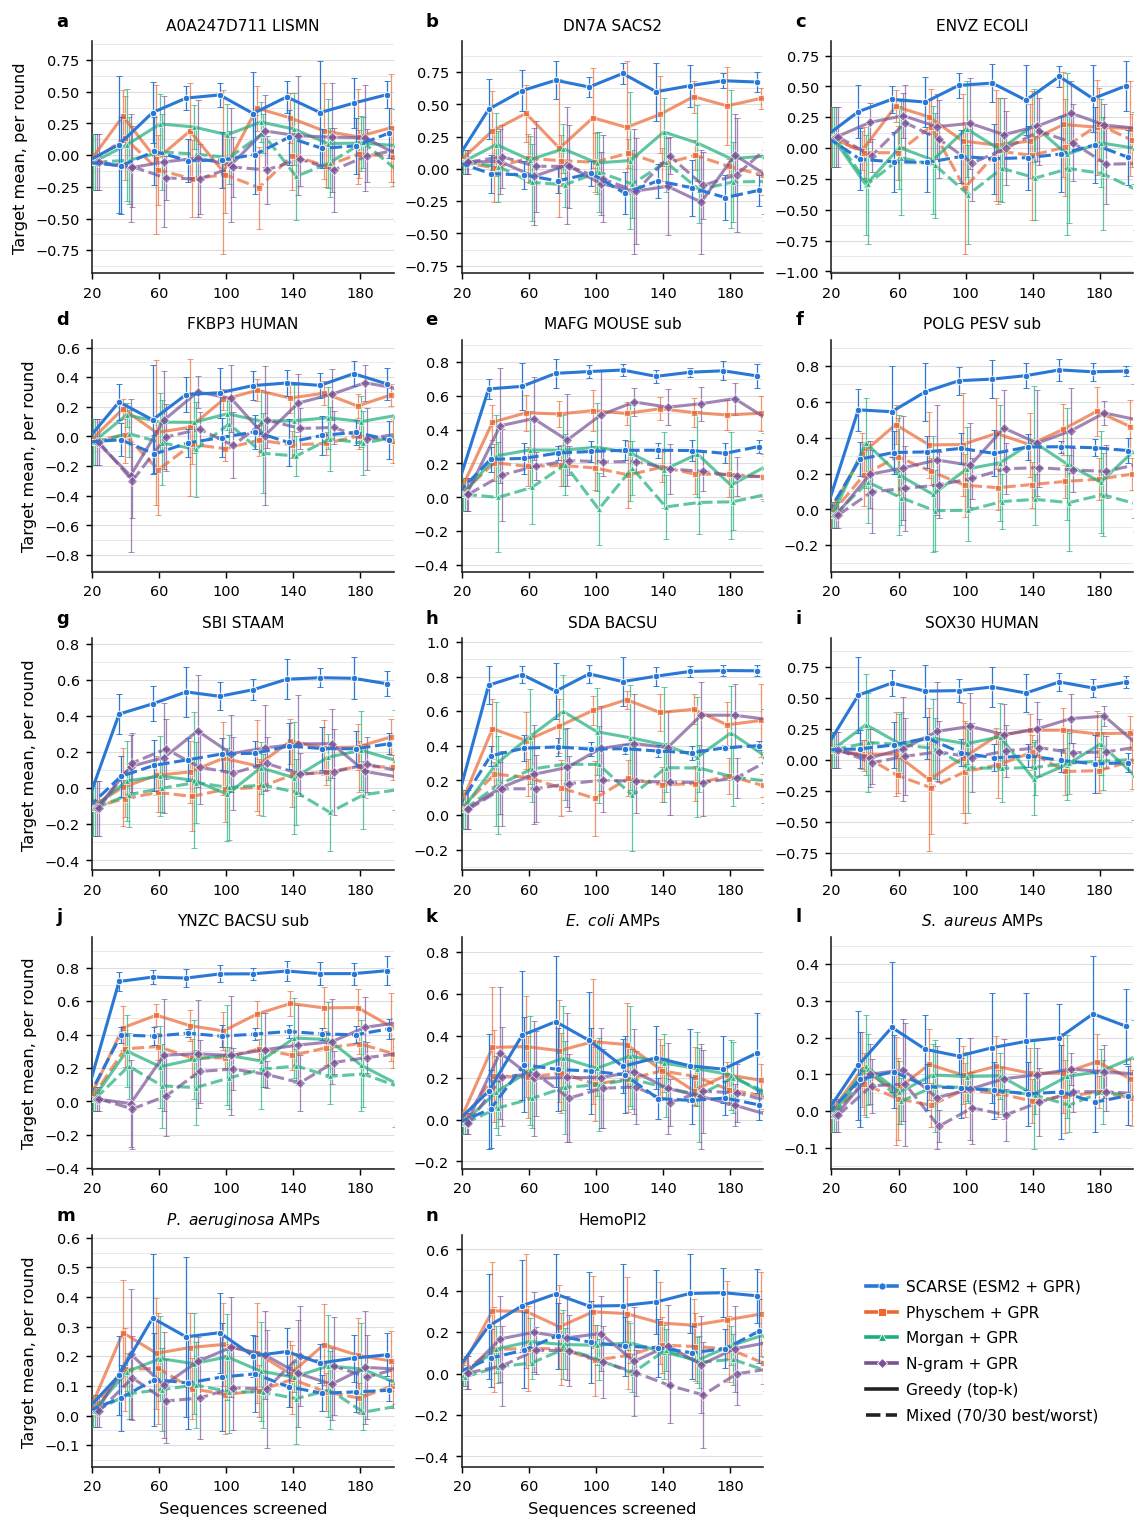

Saved workflow_grid_cumulative.png / .pdf


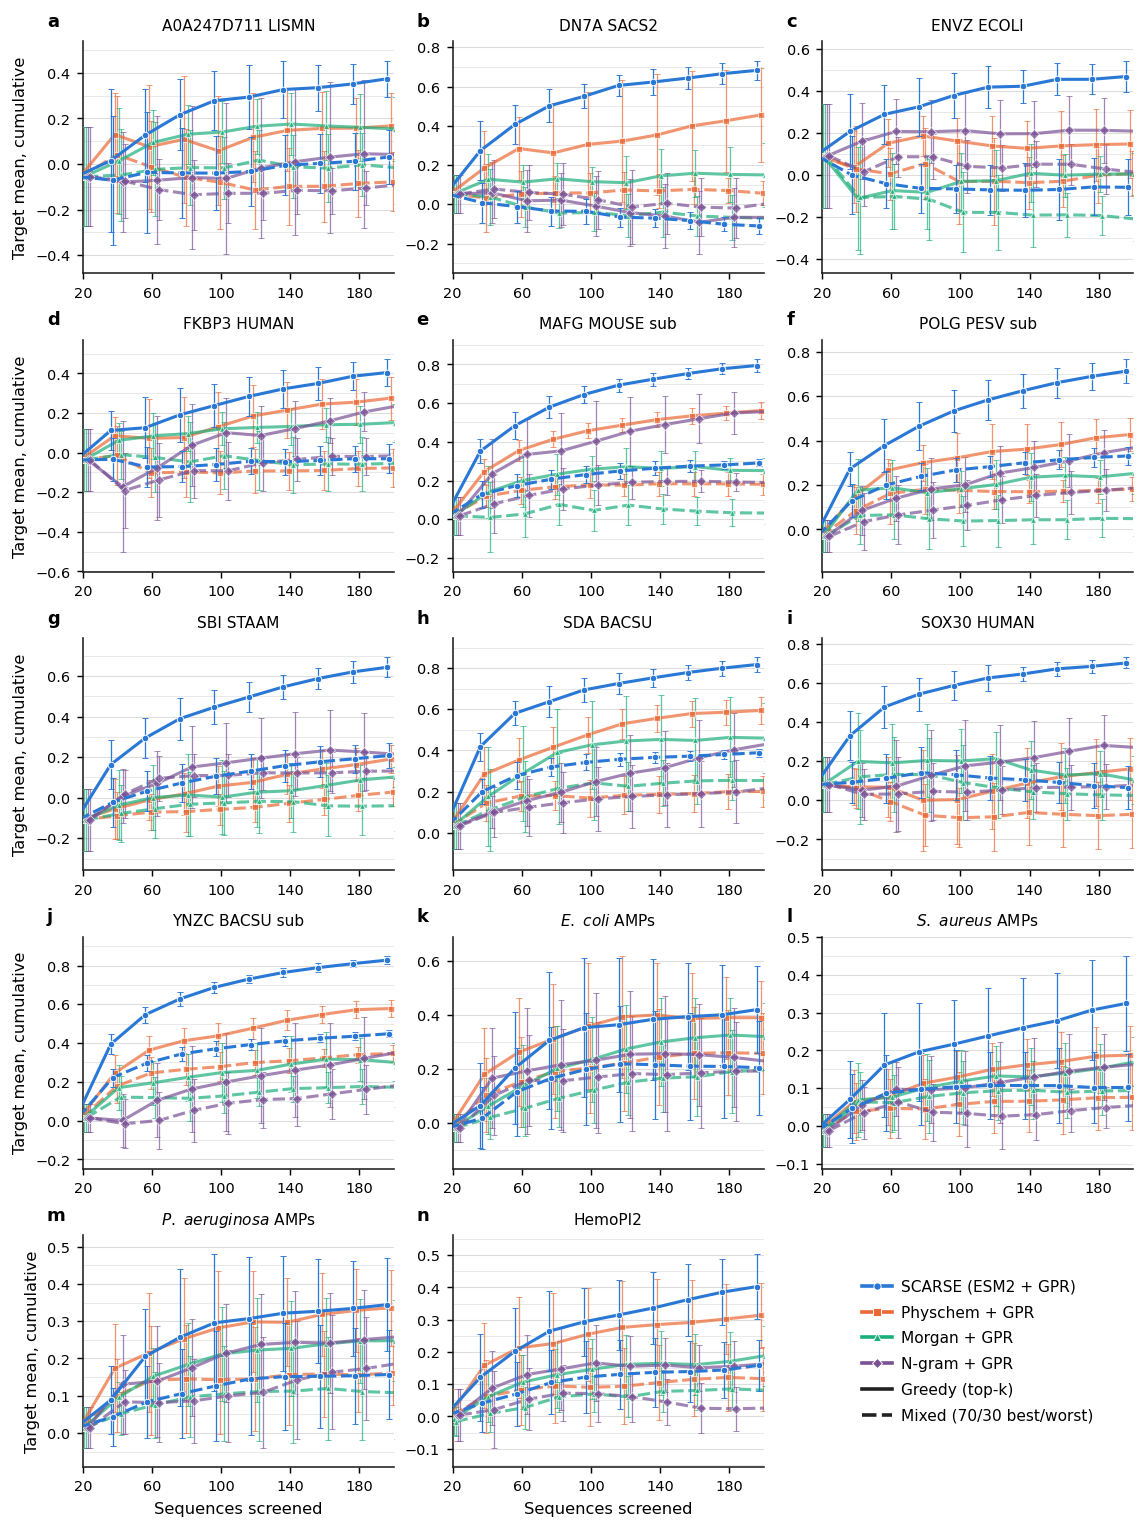

Saved workflow_grid_top10.png / .pdf


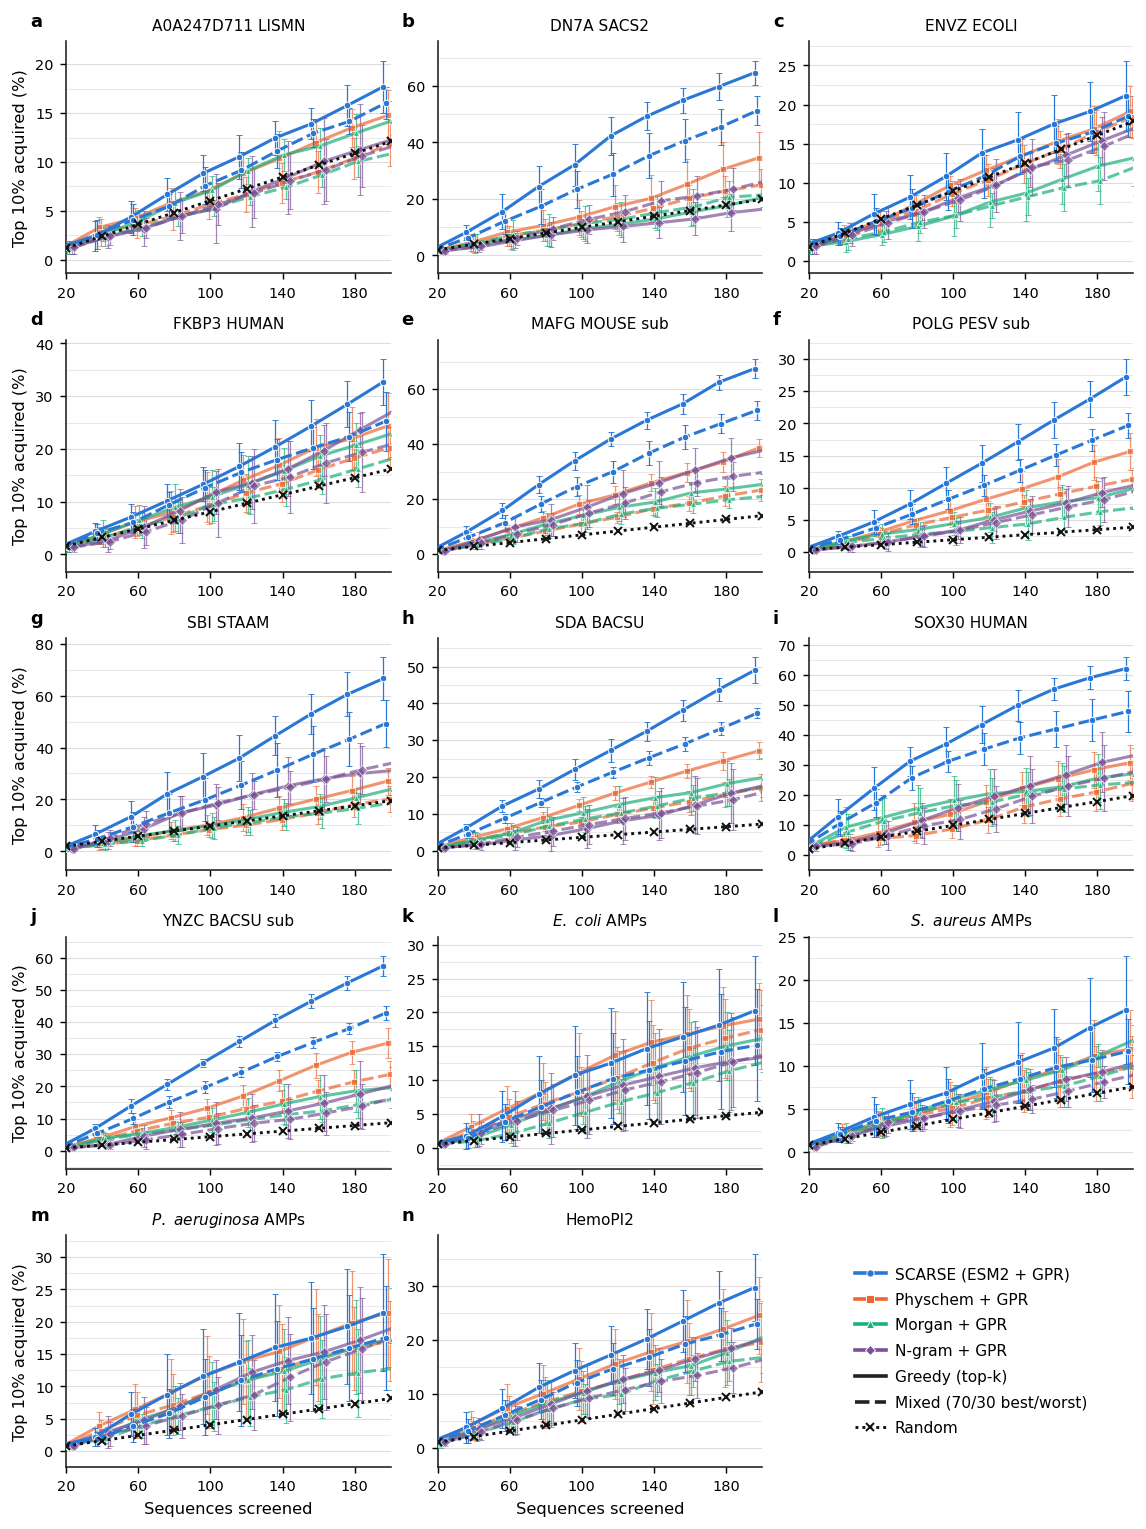

In [5]:
def figure_grid(metric, dataset_sizes, datasets=None, n_cols=3,
                reps=None, acqs=None, panel_h=2.15, legend_style="split"):
    datasets = datasets or present_datasets
    n = len(datasets)
    n_cols = min(n_cols, n)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.9 * n_cols, panel_h * n_rows + 0.9),
                             squeeze=False, layout="constrained")
    letters = string.ascii_lowercase
    for i, dataset in enumerate(datasets):
        ax = axes[i // n_cols][i % n_cols]
        draw_series(ax, dataset, metric, dataset_sizes, reps, acqs)
        ax.set_title(pretty_dataset(dataset), fontsize=8.5)
        ax.annotate(letters[i], xy=(0, 1), xycoords="axes fraction",
                    xytext=(-20, 6), textcoords="offset points",
                    fontsize=10, fontweight="bold", va="bottom")
        if i % n_cols == 0:
            ax.set_ylabel(METRICS[metric])
        if i // n_cols == n_rows - 1:
            ax.set_xlabel("Sequences screened")
    H = legend_handles(reps, acqs,
                       show_random=(metric == "Top 10% peptides selected (%)"),
                       style=legend_style)

    empty = list(range(n, n_rows * n_cols))       # panels with no dataset
    if empty:
        # Put the legend inside the first free panel instead of above the
        # figure, so the empty grid cell is used rather than wasted.
        lax = axes[empty[0] // n_cols][empty[0] % n_cols]
        lax.axis("off")
        lax.legend(handles=H, loc="center", frameon=False, ncol=1,
                   handletextpad=0.6, labelspacing=0.7, borderaxespad=0.2,
                   fontsize=8.5)
        for j in empty[1:]:                       # blank any further spare panels
            axes[j // n_cols][j % n_cols].axis("off")
    else:
        fig.legend(handles=H, loc="outside upper center", ncol=min(len(H), 5),
                   frameon=False, columnspacing=1.4, handletextpad=0.5)
    tag = ("top10" if "Top 10" in metric else
           "round" if "Round" in metric else "cumulative")
    save(fig, f"workflow_grid_{tag}")
    plt.show()
    return fig


for _m in METRICS:
    figure_grid(_m, dataset_sizes)